# ILP for Optical Network RWA
Equivalent Python implementation of main_ILP.m

In [1]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds
import matplotlib.pyplot as plt

## Loading Parameters

In [2]:
maxWavelengths = 8    # W
maxTransceivers = 1000000  # A
W = maxWavelengths
A = maxTransceivers

normalized_demand_matrix = np.array([
    [0, 0, 0, 1/3],
    [0, 0, 1/3, 1/3],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
])

# Path Capacities
Capacity124 = 100
Capacity134 = 100
Capacity14 = 100
Capacity243 = 100
Capacity213 = 100
Capacity2143 = 50
Capacity24 = 250
Capacity2134 = 100
Capacity214 = 50

## Variable Index Mapping
Variables: x[path, wavelength] (9 paths × W wavelengths), T[3], TN[1]

Total: 9*W + 3 + 1 = 76 variables (when W=8)

In [3]:
# Path indices
paths = ['p124', 'p134', 'p14', 'p243', 'p213', 'p2143', 'p24', 'p2134', 'p214']
n_paths = len(paths)
pathIdx = {p: i for i, p in enumerate(paths)}

# Variable layout: x[path][wavelength] flattened, then T[3], then TN
n_x = n_paths * W  # 72
n_T = 3
n_TN = 1
n_vars = n_x + n_T + n_TN  # 76

def x_idx(path, w):
    """Get variable index for x[path, wavelength]"""
    return pathIdx[path] * W + w

def T_idx(demand):
    """Get variable index for T[demand]: 0='14', 1='23', 2='24'"""
    return n_x + demand

TN_idx = n_x + n_T  # index for TN

## Build ILP Model

In [4]:
# Objective: maximize TN -> minimize -TN
c = np.zeros(n_vars)
c[TN_idx] = -1

# Inequality constraints
A_ub = []
b_ub = []

# Wavelength non-overlapping constraints (for each wavelength w)
for w in range(W):
    # LINK12: x('p124', w) <= 1
    row = np.zeros(n_vars)
    row[x_idx('p124', w)] = 1
    A_ub.append(row); b_ub.append(1)
    
    # LINK13: x('p134',w) + x('p213',w) + x('p2134',w) <= 1
    row = np.zeros(n_vars)
    row[x_idx('p134', w)] = 1
    row[x_idx('p213', w)] = 1
    row[x_idx('p2134', w)] = 1
    A_ub.append(row); b_ub.append(1)
    
    # LINK14: x('p14',w) + x('p2143',w) + x('p214',w) <= 1
    row = np.zeros(n_vars)
    row[x_idx('p14', w)] = 1
    row[x_idx('p2143', w)] = 1
    row[x_idx('p214', w)] = 1
    A_ub.append(row); b_ub.append(1)
    
    # LINK24: x('p124',w) + x('p243',w) + x('p24',w) <= 1
    row = np.zeros(n_vars)
    row[x_idx('p124', w)] = 1
    row[x_idx('p243', w)] = 1
    row[x_idx('p24', w)] = 1
    A_ub.append(row); b_ub.append(1)
    
    # LINK34: x('p134',w) + x('p2134',w) <= 1
    row = np.zeros(n_vars)
    row[x_idx('p134', w)] = 1
    row[x_idx('p2134', w)] = 1
    A_ub.append(row); b_ub.append(1)
    
    # LINK21: x('p213',w) + x('p2143',w) + x('p2134',w) + x('p214',w) <= 1
    row = np.zeros(n_vars)
    row[x_idx('p213', w)] = 1
    row[x_idx('p2143', w)] = 1
    row[x_idx('p2134', w)] = 1
    row[x_idx('p214', w)] = 1
    A_ub.append(row); b_ub.append(1)
    
    # LINK43: x('p243',w) + x('p2143',w) <= 1
    row = np.zeros(n_vars)
    row[x_idx('p243', w)] = 1
    row[x_idx('p2143', w)] = 1
    A_ub.append(row); b_ub.append(1)

# Transceiver cost: sum(sum(x)) <= A
row = np.zeros(n_vars)
row[:n_x] = 1
A_ub.append(row); b_ub.append(A)

# Demand-Network constraints: TN <= (1/d_ij) * T_ij
# TN - (1/d_14)*T_14 <= 0
row = np.zeros(n_vars)
row[TN_idx] = 1
row[T_idx(0)] = -1 / normalized_demand_matrix[0, 3]
A_ub.append(row); b_ub.append(0)

# TN - (1/d_23)*T_23 <= 0
row = np.zeros(n_vars)
row[TN_idx] = 1
row[T_idx(1)] = -1 / normalized_demand_matrix[1, 2]
A_ub.append(row); b_ub.append(0)

# TN - (1/d_24)*T_24 <= 0
row = np.zeros(n_vars)
row[TN_idx] = 1
row[T_idx(2)] = -1 / normalized_demand_matrix[1, 3]
A_ub.append(row); b_ub.append(0)

A_ub = np.array(A_ub)
b_ub = np.array(b_ub)

In [5]:
# Equality constraints: Demand-Capacity
A_eq = []
b_eq = []

# T('14') == sum(100*x('p124',:) + 100*x('p134',:) + 100*x('p14',:))
row = np.zeros(n_vars)
for w in range(W):
    row[x_idx('p124', w)] = Capacity124
    row[x_idx('p134', w)] = Capacity134
    row[x_idx('p14', w)] = Capacity14
row[T_idx(0)] = -1
A_eq.append(row); b_eq.append(0)

# T('23') == sum(100*x('p243',:) + 100*x('p213',:) + 50*x('p2143',:))
row = np.zeros(n_vars)
for w in range(W):
    row[x_idx('p243', w)] = Capacity243
    row[x_idx('p213', w)] = Capacity213
    row[x_idx('p2143', w)] = Capacity2143
row[T_idx(1)] = -1
A_eq.append(row); b_eq.append(0)

# T('24') == sum(250*x('p24',:) + 100*x('p2134',:) + 50*x('p214',:))
row = np.zeros(n_vars)
for w in range(W):
    row[x_idx('p24', w)] = Capacity24
    row[x_idx('p2134', w)] = Capacity2134
    row[x_idx('p214', w)] = Capacity214
row[T_idx(2)] = -1
A_eq.append(row); b_eq.append(0)

A_eq = np.array(A_eq)
b_eq = np.array(b_eq)

## Solve ILP

In [6]:
# Bounds: x >= 0 (integer), T >= 0, TN >= 0
bounds = Bounds(
    lb=np.zeros(n_vars),
    ub=np.full(n_vars, np.inf)
)

# Integrality: x are integers, T and TN are continuous
integrality = np.zeros(n_vars)
integrality[:n_x] = 1  # x variables are integers

# Constraints
constraints = [
    LinearConstraint(A_ub, -np.inf, b_ub),
    LinearConstraint(A_eq, b_eq, b_eq)
]

result = milp(c, constraints=constraints, bounds=bounds, integrality=integrality)

if result.success:
    print(f"Optimal network throughput: {result.x[TN_idx]:.6g} [Gbps]")
    print(f"T_14 = {result.x[T_idx(0)]:.2f}")
    print(f"T_23 = {result.x[T_idx(1)]:.2f}")
    print(f"T_24 = {result.x[T_idx(2)]:.2f}")
else:
    print("Optimization failed!")

Optimal network throughput: 3000 [Gbps]
T_14 = 1000.00
T_23 = 1000.00
T_24 = 1000.00


## Extract Solution & Visualization

In [7]:
# Extract x values as 2D array [path, wavelength]
x_values = result.x[:n_x].reshape(n_paths, W)

# Build link spectrum
link12 = x_values[pathIdx['p124'], :]

link13 = (x_values[pathIdx['p134'], :] + 
          x_values[pathIdx['p213'], :] + 
          x_values[pathIdx['p2134'], :])

link14 = (x_values[pathIdx['p14'], :] + 
          x_values[pathIdx['p2143'], :] + 
          x_values[pathIdx['p214'], :])

link24 = (x_values[pathIdx['p124'], :] + 
          x_values[pathIdx['p243'], :] + 
          x_values[pathIdx['p24'], :])

link34 = (x_values[pathIdx['p134'], :] + 
          x_values[pathIdx['p2134'], :])

link21 = (x_values[pathIdx['p213'], :] + 
          x_values[pathIdx['p2143'], :] + 
          x_values[pathIdx['p2134'], :] + 
          x_values[pathIdx['p214'], :])

link43 = (x_values[pathIdx['p243'], :] + 
          x_values[pathIdx['p2143'], :])

networkSpectrum = np.array([link12, link13, link14, link24, link34, link21, link43])

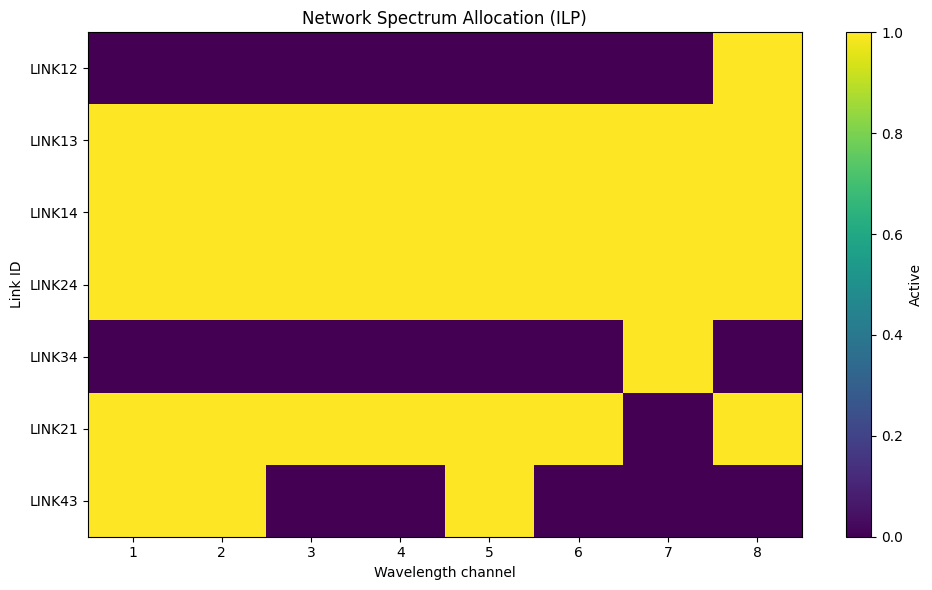

In [8]:
plt.figure(figsize=(10, 6))
plt.imshow(networkSpectrum, aspect='auto', cmap='viridis')
plt.colorbar(label='Active')
plt.xlabel("Wavelength channel")
plt.ylabel("Link ID")
plt.xticks(range(W), range(1, W + 1))
plt.yticks(range(7), ['LINK12', 'LINK13', 'LINK14', 'LINK24', 'LINK34', 'LINK21', 'LINK43'])
plt.title("Network Spectrum Allocation (ILP)")
plt.tight_layout()
plt.show()